In [1]:
# %load ModalBench_v2_Complete.py
#!/usr/bin/env python3
"""
================================================================================
ModalBench v2 — Complete Codebase (Post-Review)
================================================================================
ICLR 2026 Workshop: Logical Reasoning of Large Language Models

Single-file pipeline. Run top-to-bottom in Google Colab.

Addresses all review feedback:
  W1: Dual-track presentation (formal + natural language)
  W2: 4 prompting strategies compared
  W3: Deontic paradoxes (Ross, Chisholm, Good Samaritan, Gentle Murderer)
  W4: Deep diagnostic analysis (per-axiom, □ vs ◇, implicit S5 bias, etc.)
  W5: Related work positioning (paper text, not code)
  + Free model evaluation (Gemini, Groq, Cerebras, OpenRouter)
  + Google Drive save/restore
  + Stratified sampling for efficiency
================================================================================
"""

# ── Cell 1: Install & Import ─────────────────────────────────────────────────
!pip install -q openai google-generativeai matplotlib seaborn scipy tqdm
!pip install -q google-genai openai
import os, sys, json, re, random, time, math, hashlib, itertools
from enum import Enum
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Tuple, Optional, Set, Any
from collections import defaultdict, Counter
from copy import deepcopy

import numpy as np
import pandas as pd

_IN_COLAB = "google.colab" in sys.modules
if not _IN_COLAB:
    import matplotlib; matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
# Add this to your imports in Cell 1
import asyncio
from openai import AsyncOpenAI

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw): return it

SEED = 42
random.seed(SEED); np.random.seed(SEED)
print("✅ Imports done")


✅ Imports done


In [2]:

# ── Cell 2: Configuration ────────────────────────────────────────────────────
import os
from google.colab import userdata

# Safely load keys from Colab Secrets into the environment
os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
os.environ["CEREBRAS_API_KEY"] = userdata.get("CEREBRAS_API_KEY")
os.environ["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")

class C:
    """Central config — edit freely."""
    # API keys (set via Colab Secrets or os.environ)
    GOOGLE_KEY   = os.environ.get("GOOGLE_API_KEY", "")
    GROQ_KEY     = os.environ.get("GROQ_API_KEY", "")
    CEREBRAS_KEY = os.environ.get("CEREBRAS_API_KEY", "")
    OPENROUTER_KEY = os.environ.get("OPENROUTER_API_KEY", "")

    # Evaluation Config
    MAX_RETRIES = 8      # Increased from 3
    RETRY_DELAY = 2

    # Benchmark
    WORLDS_RANGE = (2, 7)
    PROPS_RANGE  = (2, 5)
    PROBLEMS_PER_CELL = 100   # per system×tier — total ≈ 1500

    # Evaluation
    MAX_RETRIES = 3; RETRY_DELAY = 2
    TEMPERATURE = 0.0; MAX_TOKENS = 1024

    # Paths
    OUT = "modalbench_v2"
    FIG = "figures"

os.makedirs(C.OUT, exist_ok=True)
os.makedirs(f"{C.OUT}/{C.FIG}", exist_ok=True)


In [3]:

# ── Cell 3: Kripke Semantics Engine ──────────────────────────────────────────

class Sys(Enum):
    K="K"; T="T"; S4="S4"; S5="S5"; D="D"

@dataclass
class Frame:
    worlds: List[str]
    rels: List[Tuple[str,str]]
    system: Sys
    def acc(self, w): return {b for a,b in self.rels if a==w}
    def is_reflexive(self):
        s=set(self.rels); return all((w,w) in s for w in self.worlds)
    def is_transitive(self):
        s=set(self.rels)
        for a,b in self.rels:
            for b2,c in self.rels:
                if b==b2 and (a,c) not in s: return False
        return True
    def is_serial(self):
        src={a for a,_ in self.rels}; return all(w in src for w in self.worlds)
    def is_euclidean(self):
        s=set(self.rels)
        for w in self.worlds:
            a=self.acc(w)
            for x,y in itertools.product(a,a):
                if (x,y) not in s: return False
        return True
    def density(self):
        n=len(self.worlds); return len(self.rels)/(n*n) if n else 0

@dataclass
class Model:
    frame: Frame
    val: Dict[str,Dict[str,bool]]
    props: List[str]

class FT(Enum):
    ATOM="atom"; NOT="not"; AND="and"; OR="or"; IMP="imp"
    BOX="box"; DIA="dia"; OB="ob"; PE="pe"; FO="fo"

@dataclass
class F:
    t: FT
    atom: Optional[str]=None
    sub: Optional['F']=None
    l: Optional['F']=None
    r: Optional['F']=None

    def ev(self, m: Model, w: str) -> bool:
        if self.t==FT.ATOM: return m.val[w].get(self.atom, False)
        if self.t==FT.NOT:  return not self.sub.ev(m,w)
        if self.t==FT.AND:  return self.l.ev(m,w) and self.r.ev(m,w)
        if self.t==FT.OR:   return self.l.ev(m,w) or self.r.ev(m,w)
        if self.t==FT.IMP:  return (not self.l.ev(m,w)) or self.r.ev(m,w)
        if self.t in (FT.BOX, FT.OB):
            a=m.frame.acc(w); return all(self.sub.ev(m,x) for x in a) if a else True
        if self.t in (FT.DIA, FT.PE):
            a=m.frame.acc(w); return any(self.sub.ev(m,x) for x in a)
        if self.t==FT.FO:
            return F(FT.BOX, sub=F(FT.NOT, sub=self.sub)).ev(m,w)
        raise ValueError(self.t)

    def s(self, d=False) -> str:
        if self.t==FT.ATOM: return self.atom
        if self.t==FT.NOT:
            i=self.sub.s(d)
            return f"¬{i}" if self.sub.t==FT.ATOM else f"¬({i})"
        if self.t==FT.AND:  return f"({self.l.s(d)} ∧ {self.r.s(d)})"
        if self.t==FT.OR:   return f"({self.l.s(d)} ∨ {self.r.s(d)})"
        if self.t==FT.IMP:  return f"({self.l.s(d)} → {self.r.s(d)})"
        if self.t==FT.BOX:  return f"{'OB' if d else '□'}({self.sub.s(d)})"
        if self.t==FT.DIA:  return f"{'PE' if d else '◇'}({self.sub.s(d)})"
        if self.t==FT.OB:   return f"OB({self.sub.s(True)})"
        if self.t==FT.PE:   return f"PE({self.sub.s(True)})"
        if self.t==FT.FO:   return f"FO({self.sub.s(True)})"
        return "?"

    def depth(self) -> int:
        if self.t==FT.ATOM: return 0
        if self.sub is not None:
            d = 1 if self.t in (FT.BOX,FT.DIA,FT.OB,FT.PE,FT.FO) else 0
            return d + self.sub.depth()
        return max(self.l.depth(), self.r.depth())

    def complexity(self) -> int:
        if self.t==FT.ATOM: return 1
        if self.sub is not None: return 1+self.sub.complexity()
        return 1+self.l.complexity()+self.r.complexity()

# Constructors
def A(n):       return F(FT.ATOM, atom=n)
def N(f):       return F(FT.NOT, sub=f)
def An(a,b):    return F(FT.AND, l=a, r=b)
def Or(a,b):    return F(FT.OR, l=a, r=b)
def Imp(a,b):   return F(FT.IMP, l=a, r=b)
def Bx(f):      return F(FT.BOX, sub=f)
def Di(f):      return F(FT.DIA, sub=f)
def Ob(f):      return F(FT.OB, sub=f)
def Pe(f):      return F(FT.PE, sub=f)
def Fo(f):      return F(FT.FO, sub=f)

print("✅ Kripke engine loaded")


✅ Kripke engine loaded


In [4]:

# ── Cell 4: Frame & Model Generators ─────────────────────────────────────────

class FG:
    """Frame generators per modal system."""
    @staticmethod
    def _w(n): return [f"w{i}" for i in range(n)]

    @staticmethod
    def K(n):
        w=FG._w(n); r=[(a,b) for a in w for b in w if random.random()<0.4]
        if not r: r=[(random.choice(w), random.choice(w))]
        return Frame(w,r,Sys.K)

    @staticmethod
    def T(n):
        w=FG._w(n); r=[(x,x) for x in w]
        r+=[(a,b) for a in w for b in w if a!=b and random.random()<0.35]
        return Frame(w,list(set(r)),Sys.T)

    @staticmethod
    def S4(n):
        w=FG._w(n); s={(x,x) for x in w}
        for a in w:
            for b in w:
                if a!=b and random.random()<0.3: s.add((a,b))
        changed=True
        while changed:
            changed=False; new=set()
            for a,b in s:
                for b2,c in s:
                    if b==b2 and (a,c) not in s: new.add((a,c)); changed=True
            s|=new
        return Frame(w,list(s),Sys.S4)

    @staticmethod
    def S5(n):
        w=FG._w(n); nc=random.randint(1,min(3,n)); random.shuffle(w)
        cls=[[] for _ in range(nc)]
        for i,x in enumerate(w): cls[i%nc].append(x)
        s=set()
        for c in cls:
            for a in c:
                for b in c: s.add((a,b))
        return Frame(w,list(s),Sys.S5)

    @staticmethod
    def D(n):
        w=FG._w(n); s=set()
        for x in w:
            for t in random.sample(w, random.randint(1,max(1,n//2))):
                s.add((x,t))
        for a in w:
            for b in w:
                if random.random()<0.2: s.add((a,b))
        return Frame(w,list(s),Sys.D)

    @staticmethod
    def make(sys, n):
        return {Sys.K:FG.K, Sys.T:FG.T, Sys.S4:FG.S4, Sys.S5:FG.S5, Sys.D:FG.D}[sys](n)

    @staticmethod
    def validate(frame):
        s=frame.system
        if s==Sys.T and not frame.is_reflexive(): return False
        if s==Sys.S4 and not (frame.is_reflexive() and frame.is_transitive()): return False
        if s==Sys.S5 and not (frame.is_reflexive() and frame.is_transitive() and frame.is_euclidean()): return False
        if s==Sys.D and not frame.is_serial(): return False
        return True


ALETHIC_PROPS = ["p","q","r","s","t"]
DEONTIC_PROPS = ["paying_taxes","keeping_promises","telling_truth",
                 "helping_others","following_rules","respecting_privacy",
                 "reporting_crimes","recycling","voting","being_honest"]

def make_model(frame, n_props, deontic=False):
    pool = DEONTIC_PROPS if deontic else ALETHIC_PROPS
    props = random.sample(pool, min(n_props, len(pool)))
    val = {w: {p: random.random()<0.5 for p in props} for w in frame.worlds}
    return Model(frame, val, props)

print("✅ Generators loaded")


✅ Generators loaded


In [5]:

# ── Cell 5: Formula Pools (3 Tiers) + Deontic Paradoxes (W3) ────────────────

def tier1(props, deontic=False):
    fs=[]
    for pn in props:
        p=A(pn)
        if deontic:
            fs+=[Ob(p), Pe(p), Fo(p), Ob(N(p)), Pe(N(p))]
        else:
            fs+=[Bx(p), Di(p), Bx(N(p)), Di(N(p)), N(Bx(p)), N(Di(p))]
    if len(props)>=2:
        p,q=A(props[0]),A(props[1])
        if deontic: fs+=[Ob(An(p,q)), Pe(Or(p,q))]
        else: fs+=[Bx(An(p,q)), Di(An(p,q)), Bx(Or(p,q)), Di(Or(p,q)), Bx(Imp(p,q))]
    return [{"f":f, "tag":None, "key":f"T1:{f.s(deontic)}", "para":None} for f in fs if f.depth()<=1]

def tier2(props, deontic=False):
    fs=[]
    for pn in props:
        p=A(pn)
        if deontic:
            fs+=[Ob(Pe(p)), Pe(Ob(p)), Ob(Ob(p)), Fo(Pe(p))]
        else:
            fs+=[Bx(Bx(p)), Di(Di(p)), Bx(Di(p)), Di(Bx(p)), Bx(Di(N(p))), N(Bx(Di(p)))]
    if len(props)>=2:
        p,q=A(props[0]),A(props[1])
        if deontic: fs+=[Ob(An(Pe(p),Pe(q))), Imp(Ob(p),Pe(q))]
        else: fs+=[Bx(An(Di(p),Di(q))), Di(An(Bx(p),Di(q))), Imp(Bx(p),Di(q)), Bx(Imp(p,Di(q)))]
    return [{"f":f, "tag":None, "key":f"T2:{f.s(deontic)}", "para":None} for f in fs if f.depth()>=2]

def tier3_alethic(props, sys):
    p=A(props[0]); q=A(props[1]) if len(props)>=2 else A(props[0])
    items = [
        (Imp(Bx(p),p),                    "T",  sys in (Sys.T,Sys.S4,Sys.S5)),
        (Imp(Bx(p),Bx(Bx(p))),           "4",  sys in (Sys.S4,Sys.S5)),
        (Imp(Di(p),Bx(Di(p))),            "5",  sys==Sys.S5),
        (Imp(p, Bx(Di(p))),               "B",  sys==Sys.S5),
        (Imp(Bx(Imp(p,q)),Imp(Bx(p),Bx(q))), "K", True),
        (Imp(Bx(p),N(Di(N(p)))),          "dual", True),
        (Imp(N(Di(N(p))),Bx(p)),          "dual_rev", True),
        (Imp(Bx(An(p,q)),An(Bx(p),Bx(q))), "dist", True),
        (Imp(Di(Bx(p)),Bx(Di(p))),        "Barcan", False),
        (Imp(Bx(Bx(Bx(p))),Bx(p)),        "triple", sys in (Sys.S4,Sys.S5)),
        (Imp(Bx(Di(p)),Di(Bx(p))),        "McKinsey", False),
        # Non-axiom formulas for label balance
        (An(Bx(p),Di(N(p))),              None, False),
        (Or(Bx(p),Bx(N(p))),             None, False),
        (Imp(Di(p),p),                    "conv_T", False),  # converse of T — NOT valid
    ]
    return [{"f":f,"tag":tag,"key":f"T3:{tag or f.s()}","para":None} for f,tag,_ in items]

def tier3_deontic(props, sys):
    p=A(props[0]); q=A(props[1]) if len(props)>=2 else A(props[0])
    items = [
        (Imp(Ob(p),Pe(p)),                           "D",       None),
        (Imp(Ob(p),Di(p)),                            "ought_can",None),
        (N(An(Ob(p),Ob(N(p)))),                      "no_conflict",None),
        (Imp(Ob(p),Ob(Or(p,q))),                     "Ross",     "Ross"),
        (Imp(Fo(p),N(Pe(p))),                         "FO_PE",   None),
        (Imp(Ob(Ob(p)),Ob(p)),                        "OB_4",    None),
        (Imp(Pe(An(p,q)),An(Pe(p),Pe(q))),            "PE_dist", None),
        # Deontic paradoxes (W3)
        (Imp(Ob(An(p,N(q))),An(Ob(p),Ob(N(q)))),     "GoodSam", "Good_Samaritan"),
        (Imp(An(Ob(p),N(p)),Ob(N(q))),                "Chisholm","Chisholm"),
        (An(Ob(p),Imp(N(p),Ob(q))),                   "Gentle",  "Gentle_Murderer"),
        (An(Fo(p),Pe(p)),                              "FO_PE_contra","FO_PE_Contradiction"),
    ]
    return [{"f":f,"tag":tag,"key":f"T3D:{tag}","para":para} for f,tag,para in items]

def get_pool(props, sys, tier, deontic):
    if tier==1: return tier1(props, deontic)
    if tier==2: return tier2(props, deontic)
    return tier3_deontic(props,sys) if deontic else tier3_alethic(props,sys)

print("✅ Formula pools loaded (incl. deontic paradoxes)")


✅ Formula pools loaded (incl. deontic paradoxes)


In [6]:

# ── Cell 6: Dual-Track Description Generators (W1) ──────────────────────────

WNAMES = {f"w{i}": n for i,n in enumerate(
    ["World Alpha","World Beta","World Gamma","World Delta",
     "World Epsilon","World Zeta","World Eta"])}
DSCEN = dict(paying_taxes="paying taxes", keeping_promises="keeping promises",
    telling_truth="telling the truth", helping_others="helping others",
    following_rules="following rules", respecting_privacy="respecting privacy",
    reporting_crimes="reporting crimes", recycling="recycling",
    voting="voting", being_honest="being honest")

def formal_desc(model, formula, world, deontic=False):
    """FORMAL track: explicit worlds, relations, valuations."""
    lines = []
    fr = model.frame
    lines.append(f"There are {len(fr.worlds)} possible worlds: " +
                 ", ".join(WNAMES.get(w,w) for w in fr.worlds) + ".")
    lines.append("\nAccessibility:")
    for w in fr.worlds:
        a = fr.acc(w)
        wn = WNAMES.get(w,w)
        if a:
            lines.append(f"  {wn} → {', '.join(WNAMES.get(x,x) for x in sorted(a))}")
        else:
            lines.append(f"  {wn} → (none)")
    lines.append("\nValuations:")
    for w in fr.worlds:
        wn=WNAMES.get(w,w)
        ts=[p for p,v in model.val[w].items() if v]
        fs=[p for p,v in model.val[w].items() if not v]
        if deontic:
            parts=[]
            if ts: parts.append(", ".join(DSCEN.get(p,p) for p in ts)+" practiced")
            if fs: parts.append(", ".join(DSCEN.get(p,p) for p in fs)+" not practiced")
            lines.append(f"  {wn}: {'; '.join(parts)}")
        else:
            parts=[]
            if ts: parts.append(", ".join(ts)+"=True")
            if fs: parts.append(", ".join(fs)+"=False")
            lines.append(f"  {wn}: {'; '.join(parts)}")
    wn=WNAMES.get(world,world)
    fs=formula.s(deontic)
    lines.append(f"\nEvaluating at {wn}, is this true or false?\n  {fs}")
    if deontic:
        lines.append("\nOB='obligatory', PE='permitted', FO='forbidden'.")
    else:
        lines.append("\n□='necessarily' (ALL accessible), ◇='possibly' (SOME accessible).")
    lines.append("Answer exactly 'True' or 'False', then explain.")
    return "\n".join(lines)


PROP_NL = {
    "p": "the door is locked", "q": "the window is open",
    "r": "the alarm is active", "s": "the safe contains documents",
    "t": "the lights are on",
}

def _formula_nl(f, ctx="epistemic"):
    """Recursively translate formula to NL question."""
    if f.t==FT.ATOM:
        return PROP_NL.get(f.atom, DSCEN.get(f.atom, f.atom))
    if f.t==FT.NOT:
        return f"it is NOT the case that {_formula_nl(f.sub,ctx)}"
    if f.t in (FT.BOX,FT.OB):
        inner=_formula_nl(f.sub,ctx)
        if ctx=="epistemic": return f"Alice necessarily knows that {inner}"
        return f"it is obligatory that {inner}"
    if f.t in (FT.DIA,FT.PE):
        inner=_formula_nl(f.sub,ctx)
        if ctx=="epistemic": return f"Alice considers it possible that {inner}"
        return f"it is permitted that {inner}"
    if f.t==FT.FO:
        return f"it is forbidden that {_formula_nl(f.sub,ctx)}"
    if f.t==FT.IMP:
        return f"IF {_formula_nl(f.l,ctx)} THEN {_formula_nl(f.r,ctx)}"
    if f.t==FT.AND:
        return f"BOTH ({_formula_nl(f.l,ctx)}) AND ({_formula_nl(f.r,ctx)})"
    if f.t==FT.OR:
        return f"EITHER ({_formula_nl(f.l,ctx)}) OR ({_formula_nl(f.r,ctx)})"
    return f.s()

ROOMS = ["Room A","Room B","Room C","Room D","Room E","Room F","Room G"]
DISTS = ["District Alpha","District Beta","District Gamma","District Delta",
         "District Epsilon","District Zeta","District Eta"]

def nl_desc(model, formula, world, deontic=False):
    """NATURAL LANGUAGE track: narrative scenario (W1)."""
    fr=model.frame; lines=[]
    if deontic:
        nm={w:DISTS[i] for i,w in enumerate(fr.worlds)}
        lines.append("Consider a legal system with several jurisdictions.")
        lines.append("Each jurisdiction's regulations constrain what is "
                     "obligatory/permitted in jurisdictions it influences.\n")
        for w in fr.worlds:
            a=fr.acc(w); others=[nm[x] for x in sorted(a) if x!=w]
            if w in a and others:
                lines.append(f"{nm[w]} regulates itself and influences {', '.join(others)}.")
            elif w in a:
                lines.append(f"{nm[w]} only regulates itself.")
            elif others:
                lines.append(f"{nm[w]} influences {', '.join(others)} (not itself).")
            else:
                lines.append(f"{nm[w]} has no regulatory influence.")
        lines.append("\nCurrent practices:")
        for w in fr.worlds:
            ts=[DSCEN.get(p,p) for p,v in model.val[w].items() if v]
            fs=[DSCEN.get(p,p) for p,v in model.val[w].items() if not v]
            parts=[]
            if ts: parts.append(", ".join(ts)+" is practiced")
            if fs: parts.append(", ".join(fs)+" is not practiced")
            lines.append(f"  {nm[w]}: {'; '.join(parts)}")
        lines.append(f"\nEvaluating from {nm[world]}:")
        lines.append(f"Question: Is it true that {_formula_nl(formula,'legal')}?")
        lines.append("'Obligatory' = true in ALL influenced jurisdictions. "
                     "'Permitted' = true in SOME.")
    else:
        nm={w:ROOMS[i] for i,w in enumerate(fr.worlds)}
        lines.append("Alice is exploring a building. Some rooms have one-way "
                     "observation windows into other rooms.\n")
        for w in fr.worlds:
            a=fr.acc(w); others=[nm[x] for x in sorted(a) if x!=w]
            if w in a and others:
                lines.append(f"From {nm[w]}, Alice can see {nm[w]} itself and {', '.join(others)}.")
            elif w in a:
                lines.append(f"From {nm[w]}, Alice can only see {nm[w]} itself (mirror).")
            elif others:
                lines.append(f"From {nm[w]}, Alice can see into {', '.join(others)}.")
            else:
                lines.append(f"From {nm[w]}, Alice cannot see any room.")
        lines.append("\nFacts in each room:")
        for w in fr.worlds:
            facts=[]
            for p in model.props:
                v=model.val[w].get(p,False)
                pnl=PROP_NL.get(p,p)
                facts.append(pnl if v else f"it is NOT the case that {pnl}")
            lines.append(f"  {nm[w]}: {'; '.join(facts)}.")
        lines.append(f"\nAlice is in {nm[world]}.")
        lines.append(f"Question: Is it true that {_formula_nl(formula,'epistemic')}?")
        lines.append("'Necessarily'=true in ALL observable rooms. "
                     "'Possibly'=true in SOME.")
    lines.append("\nAnswer exactly 'True' or 'False' and explain.")
    return "\n".join(lines)

print("✅ Dual-track generators loaded (W1)")


✅ Dual-track generators loaded (W1)


In [7]:

# ── Cell 7: BenchmarkProblem + Generation Pipeline ───────────────────────────

@dataclass
class BP:
    """Benchmark Problem."""
    id: str; system: str; tier: int; task_type: str
    presentation: str = "formal"       # "formal" or "nl"
    num_worlds: int = 0
    worlds: List[str] = field(default_factory=list)
    relations: List[Tuple[str,str]] = field(default_factory=list)
    propositions: List[str] = field(default_factory=list)
    valuation: Dict[str,Dict[str,bool]] = field(default_factory=dict)
    formula_str: str = ""
    formula_symbolic: str = ""
    evaluation_world: str = ""
    ground_truth: bool = False
    related_formulas: Optional[List[Dict]] = None
    modal_depth: int = 0
    formula_complexity: int = 0
    deontic: bool = False
    nl_description: str = ""
    axiom_tag: Optional[str] = None
    paradox_name: Optional[str] = None
    frame_density: float = 0.0
    always_valid: bool = False

_counter = 0
def _mid(sys,tier,tt):
    global _counter; _counter+=1
    return f"MB-{sys.value}-T{tier}-{tt[:2].upper()}-{_counter:04d}"

def generate_benchmark():
    """Generate full ModalBench benchmark with dual tracks."""
    problems = []
    systems_al = [Sys.K, Sys.T, Sys.S4, Sys.S5]
    systems_de = [Sys.D]

    print("=" * 60)
    print("GENERATING MODALBENCH v2")
    print("=" * 60)

    for sys_list, deontic in [(systems_al, False), (systems_de, True)]:
        for sys in sys_list:
            for tier in [1, 2, 3]:
                target = C.PROBLEMS_PER_CELL
                count_t, count_f = 0, 0
                half = target // 2
                attempts = 0

                while (count_t + count_f) < target and attempts < target * 20:
                    attempts += 1
                    nw = random.randint(*C.WORLDS_RANGE)
                    np_ = random.randint(*C.PROPS_RANGE)

                    frame = FG.make(sys, nw)
                    if not FG.validate(frame): continue
                    model = make_model(frame, np_, deontic)

                    pool = get_pool(model.props, sys, tier, deontic)
                    if not pool: continue
                    item = random.choice(pool)
                    formula = item["f"]

                    ew = random.choice(frame.worlds)
                    try:
                        gt = formula.ev(model, ew)
                    except: continue

                    # Label balance
                    if gt and count_t >= half: continue
                    if not gt and count_f >= half: continue
                    if gt: count_t += 1
                    else: count_f += 1

                    # Build both tracks
                    formal_text = formal_desc(model, formula, ew, deontic)
                    nl_text = nl_desc(model, formula, ew, deontic)

                    base = dict(
                        system=sys.value, tier=tier, task_type="qa",
                        num_worlds=nw, worlds=frame.worlds,
                        relations=frame.rels, propositions=model.props,
                        valuation=model.val, formula_str=formula.s(deontic),
                        formula_symbolic=formula.s(deontic),
                        evaluation_world=ew, ground_truth=gt,
                        modal_depth=formula.depth(),
                        formula_complexity=formula.complexity(),
                        deontic=deontic, axiom_tag=item["tag"],
                        paradox_name=item["para"],
                        frame_density=frame.density(),
                    )

                    # Formal track problem
                    problems.append(BP(id=_mid(sys,tier,"qa"),
                                       presentation="formal",
                                       nl_description=formal_text, **base))
                    # NL track problem (same ground truth)
                    problems.append(BP(id=_mid(sys,tier,"qa"),
                                       presentation="nl",
                                       nl_description=nl_text, **base))

                print(f"  {sys.value} T{tier} {'D' if deontic else 'A'}: "
                      f"{count_t+count_f} problems (T:{count_t} F:{count_f})")

    print(f"\n✅ Generated {len(problems)} total problems "
          f"({len(problems)//2} × 2 tracks)")

    # Statistics
    df = pd.DataFrame([{"sys":p.system,"tier":p.tier,"pres":p.presentation,
                         "deontic":p.deontic,"gt":p.ground_truth,
                         "nw":p.num_worlds,"depth":p.modal_depth}
                        for p in problems])
    print(f"\nBy system×tier: {df.groupby(['sys','tier']).size().to_dict()}")
    print(f"Label balance: {df['gt'].value_counts(normalize=True).to_dict()}")
    print(f"Track split: {df['pres'].value_counts().to_dict()}")
    print(f"Worlds range: {df['nw'].min()}-{df['nw'].max()}, mean={df['nw'].mean():.1f}")

    return problems

problems = generate_benchmark()


GENERATING MODALBENCH v2
  K T1 A: 100 problems (T:50 F:50)
  K T2 A: 100 problems (T:50 F:50)
  K T3 A: 100 problems (T:50 F:50)
  T T1 A: 100 problems (T:50 F:50)
  T T2 A: 100 problems (T:50 F:50)
  T T3 A: 100 problems (T:50 F:50)
  S4 T1 A: 100 problems (T:50 F:50)
  S4 T2 A: 100 problems (T:50 F:50)
  S4 T3 A: 100 problems (T:50 F:50)
  S5 T1 A: 100 problems (T:50 F:50)
  S5 T2 A: 100 problems (T:50 F:50)
  S5 T3 A: 100 problems (T:50 F:50)
  D T1 D: 100 problems (T:50 F:50)
  D T2 D: 100 problems (T:50 F:50)
  D T3 D: 100 problems (T:50 F:50)

✅ Generated 3000 total problems (1500 × 2 tracks)

By system×tier: {('D', 1): 200, ('D', 2): 200, ('D', 3): 200, ('K', 1): 200, ('K', 2): 200, ('K', 3): 200, ('S4', 1): 200, ('S4', 2): 200, ('S4', 3): 200, ('S5', 1): 200, ('S5', 2): 200, ('S5', 3): 200, ('T', 1): 200, ('T', 2): 200, ('T', 3): 200}
Label balance: {True: 0.5, False: 0.5}
Track split: {'formal': 1500, 'nl': 1500}
Worlds range: 2-7, mean=4.5


In [8]:

# ── Cell 8: Prompting Strategies (W2) ────────────────────────────────────────

STRATEGIES = {
    "zero_shot": "You are a logic expert. Answer exactly 'True' or 'False'.",
    "cot": (
        "You are a modal logic expert. Think step by step. Show reasoning, "
        "then answer exactly 'True' or 'False'."),
    "kripke_few_shot": (
        "You are a modal logic expert. Follow this procedure:\n"
        "STEP 1: List accessible worlds from evaluation world.\n"
        "STEP 2: For □P check ALL accessible. For ◇P check ANY.\n"
        "STEP 3: For nested operators, work inside-out.\n"
        "STEP 4: Build truth table if needed.\n"
        "STEP 5: Answer exactly 'True' or 'False'.\n\n"
        "Example:\nWorlds: w0,w1,w2. Rels: w0→w1, w0→w2.\n"
        "Vals: w0:p=T | w1:p=F | w2:p=T\n"
        "Q: At w0, □p? → w0 sees w1,w2. p@w1=F. So □p=False.\nAnswer: False"),
    "world_enum": (
        "You are a modal logic expert. ALWAYS:\n"
        "1. ENUMERATE all accessible worlds.\n"
        "2. TABULATE truth value of sub-formula in each.\n"
        "3. AGGREGATE: □=ALL true, ◇=ANY true.\n"
        "4. For nesting, recurse inside-out.\n"
        "Show your enumeration table. Answer exactly 'True' or 'False'."),
}

print(f"✅ {len(STRATEGIES)} prompting strategies loaded (W2)")


✅ 4 prompting strategies loaded (W2)


In [9]:

# ── Cell 9: Free Model Evaluator ─────────────────────────────────────────────

FREE_MODELS = {
    "gemini-2.0-flash": dict(prov="google", mid="gemini-2.0-flash",
        reason=False, key="GOOGLE_API_KEY", note="1500 req/day free"),
    "gemini-2.5-flash": dict(prov="google", mid="gemini-2.5-flash",
        reason=True, key="GOOGLE_API_KEY", note="500 req/day free"),
    "llama-70b-groq": dict(prov="groq", mid="llama-3.3-70b-versatile",
        reason=False, key="GROQ_API_KEY", note="1000 req/day free"),
    "qwq-32b-groq": dict(prov="groq", mid="qwen-qwq-32b",
        reason=True, key="GROQ_API_KEY", note="1000 req/day free"),
    "qwen3-235b-think-cerebras": dict(
    prov="cerebras", mid="qwen-3-235b-a22b-thinking-2507",
    reason=True, key="CEREBRAS_API_KEY",
    note="235B thinking variant, preview"
),
    "llama-70b-cerebras": dict(prov="cerebras", mid="llama-3.3-70b",
        reason=False, key="CEREBRAS_API_KEY", note="1M tok/day free"),
    "qwen3-235b-cerebras": dict(prov="cerebras", mid="qwen-3-235b",
        reason=True, key="CEREBRAS_API_KEY", note="frontier free"),
    "deepseek-r1-or": dict(prov="openrouter", mid="deepseek/deepseek-r1:free",
        reason=True, key="OPENROUTER_API_KEY", note="community free"),
}
# Patch the dictionary with the new Instruct Preview ID
FREE_MODELS["qwen3-235b-cerebras"] = dict(
    prov="cerebras",
    mid="qwen-3-235b-a22b-instruct-2507",
    reason=False,
    key="CEREBRAS_API_KEY",
    note="frontier free instruct"
)
print("✅ Qwen 3 235B model ID updated successfully.")
PROV_URL = {
    "groq": "https://api.groq.com/openai/v1",
    "cerebras": "https://api.cerebras.ai/v1",
    "openrouter": "https://openrouter.ai/api/v1",
}

def _detect_models():
    avail = {}
    for name, info in FREE_MODELS.items():
        if os.environ.get(info["key"], ""):
            avail[name] = info
    return avail


async def async_query_model(name, prompt, sys_prompt="", max_tok=1024, temp=0.0):
    """Asynchronously query a free model. Returns text or None."""
    info = FREE_MODELS.get(name)
    if not info: return None
    key = os.environ.get(info["key"], "")
    if not key: return None

    for attempt in range(C.MAX_RETRIES):
        try:
            if info["prov"] == "google":
                # --- NEW GOOGLE GENAI SDK ---
                from google import genai
                from google.genai import types

                client = genai.Client(api_key=key)

                r = await client.aio.models.generate_content(
                    model=info["mid"],
                    contents=prompt,
                    config=types.GenerateContentConfig(
                        system_instruction=sys_prompt if sys_prompt else None,
                        temperature=temp,
                        max_output_tokens=max_tok,
                    )
                )
                return r.text

            else:
                # --- OPENAI / GROQ / CEREBRAS / OPENROUTER ---
                from openai import AsyncOpenAI
                c = AsyncOpenAI(api_key=key, base_url=PROV_URL[info["prov"]])
                msgs = []
                if sys_prompt: msgs.append({"role":"system","content":sys_prompt})
                msgs.append({"role":"user","content":prompt})
                kw = dict(model=info["mid"], messages=msgs,
                          max_tokens=max_tok, temperature=temp)
                if info["prov"]=="openrouter":
                    kw["extra_headers"]={"HTTP-Referer":"https://modalbench.org",
                                         "X-Title":"ModalBench"}

                r = await c.chat.completions.create(**kw)
                return r.choices[0].message.content

        except Exception as e:
            error_msg = str(e).lower()
            if "429" in error_msg or "rate limit" in error_msg or "quota" in error_msg:
                import random
                w = (2 ** attempt) + random.uniform(0, 1)
                print(f"    ⏳ Rate limit hit for {name}. Backing off for {w:.2f}s...")
                await asyncio.sleep(w)
            else:
                w = C.RETRY_DELAY
                print(f"    ⚠️ {name} err: {e}. Retry {w}s")
                await asyncio.sleep(w)
    return None

def query_model(name, prompt, sys_prompt="", max_tok=1024, temp=0.0):
    """Query a free model. Returns text or None."""
    info = FREE_MODELS.get(name)
    if not info: return None
    key = os.environ.get(info["key"], "")
    if not key: return None

    for attempt in range(C.MAX_RETRIES):
        try:
            if info["prov"] == "google":
                import google.generativeai as genai
                genai.configure(api_key=key)
                m = genai.GenerativeModel(info["mid"],
                    system_instruction=sys_prompt or None)
                r = m.generate_content(prompt,
                    generation_config={"temperature":temp,"max_output_tokens":max_tok})
                return r.text
            else:
                from openai import OpenAI
                c = OpenAI(api_key=key, base_url=PROV_URL[info["prov"]])
                msgs = []
                if sys_prompt: msgs.append({"role":"system","content":sys_prompt})
                msgs.append({"role":"user","content":prompt})
                kw = dict(model=info["mid"], messages=msgs,
                          max_tokens=max_tok, temperature=temp)
                if info["prov"]=="openrouter":
                    kw["extra_headers"]={"HTTP-Referer":"https://modalbench.org",
                                         "X-Title":"ModalBench"}
                r = c.chat.completions.create(**kw)
                return r.choices[0].message.content
        except Exception as e:
            w = C.RETRY_DELAY * (attempt+1)
            print(f"    ⚠️ {name} err: {e}. Retry {w}s")
            time.sleep(w)
    return None

def parse_answer(resp):
    if resp is None: return None
    r = resp.lower().strip()
    for pat in [r"answer:\s*(true|false)", r"\*\*(true|false)\*\*",
                r"final answer:\s*(true|false)"]:
        m = re.search(pat, r)
        if m: return m.group(1)=="true"
    for line in reversed(r.split('\n')):
        l=line.strip().rstrip('.')
        if l in ('true',): return True
        if l in ('false',): return False
    tc=r.count('true'); fc=r.count('false')
    if tc>fc: return True
    if fc>tc: return False
    return None

avail_models = _detect_models()
print(f"✅ Free models available: {list(avail_models.keys()) or '(none — set API keys)'}")


✅ Qwen 3 235B model ID updated successfully.
✅ Free models available: ['gemini-2.0-flash', 'gemini-2.5-flash', 'llama-70b-groq', 'qwq-32b-groq', 'qwen3-235b-think-cerebras', 'llama-70b-cerebras', 'qwen3-235b-cerebras', 'deepseek-r1-or']


In [10]:

# ── Cell 10: Google Drive Checkpoint ─────────────────────────────────────────

class GDrive:
    def __init__(self, base="/content/drive/MyDrive/ICLR2026/ModalBench"):
        self.base = base
        try:
            from google.colab import drive
            drive.mount('/content/drive', force_remount=False)
        except:
            self.base = "modalbench_local_ckpt"
        for d in ["benchmarks","results","figures"]:
            os.makedirs(f"{self.base}/{d}", exist_ok=True)
        print(f"✅ GDrive ready: {self.base}")

    def save_bench(self, problems, tag="v2"):
        path = f"{self.base}/benchmarks/bench_{tag}.json"
        data = []
        for p in problems:
            d = asdict(p)
            d["relations"] = [list(r) for r in d.get("relations",[])]
            data.append(d)
        with open(path,'w') as f: json.dump(data,f)
        print(f"✅ Saved {len(data)} problems → {path}")

    def load_bench(self, tag="v2"):
        path = f"{self.base}/benchmarks/bench_{tag}.json"
        with open(path) as f: data=json.load(f)
        print(f"✅ Loaded {len(data)} problems ← {path}")
        return data

    def save_results(self, df, tag="run1"):
        path = f"{self.base}/results/res_{tag}.csv"
        df.to_csv(path, index=False)
        print(f"✅ Saved {len(df)} results → {path}")

    def load_results(self, tag="run1"):
        path = f"{self.base}/results/res_{tag}.csv"
        return pd.read_csv(path)

    def save_fig(self, fig, name):
        for ext in ['png','pdf']:
            fig.savefig(f"{self.base}/figures/{name}.{ext}",
                        dpi=300, bbox_inches='tight')
# 1. Mount Drive first
gd = GDrive()
drive_path = f"{gd.base}/partial_results.jsonl"

Mounted at /content/drive
✅ GDrive ready: /content/drive/MyDrive/ICLR2026/ModalBench


In [11]:

# ── Cell 11: Evaluation Orchestrator ─────────────────────────────────────────

def stratified_sample(problems, n=600):
    """Stratified sample preserving system×tier×track balance."""
    bk = defaultdict(list)
    for p in problems:
        bk[(p.system, p.tier, p.presentation)].append(p)
    per = max(1, n // len(bk))
    out = []
    for k, bucket in sorted(bk.items()):
        random.shuffle(bucket)
        out.extend(bucket[:per])
    random.shuffle(out)
    print(f"✅ Sampled {len(out)} from {len(problems)} ({len(bk)} strata, {per}/stratum)")
    return out

def run_evaluation(problems, models=None, strategies=None,
                   max_problems=None, delay=1.0):
    """Full evaluation: models × strategies × problems."""
    if models is None:
        models = list(avail_models.keys())[:4]
    if strategies is None:
        strategies = ["cot"]
    if max_problems:
        problems = stratified_sample(problems, max_problems)

    total = len(problems)*len(models)*len(strategies)
    print(f"\n📊 Evaluation: {len(problems)} × {len(models)} models × "
          f"{len(strategies)} strats = {total} calls")

    rows = []; done = 0
    for mn in models:
        for sn in strategies:
            sp = STRATEGIES[sn]
            ok = 0
            print(f"\n  🔄 {mn} / {sn}...")
            for i, p in enumerate(problems):
                resp = query_model(mn, p.nl_description, sys_prompt=sp)
                pred = parse_answer(resp)
                correct = pred == p.ground_truth if pred is not None else None
                if correct: ok += 1
                rows.append(dict(
                    problem_id=p.id, model=mn, prompt_strategy=sn,
                    presentation=p.presentation, system=p.system,
                    tier=p.tier, deontic=p.deontic,
                    modal_depth=p.modal_depth, num_worlds=p.num_worlds,
                    formula=p.formula_str, axiom_tag=p.axiom_tag,
                    paradox_name=p.paradox_name,
                    ground_truth=p.ground_truth, predicted=pred,
                    correct=correct,
                    response=(resp[:500] if resp else None),
                ))
                done += 1
                if done % 50 == 0:
                    print(f"    {done}/{total}")
                time.sleep(delay)
            print(f"    ✅ {mn}/{sn}: {ok}/{len(problems)} = "
                  f"{ok/max(len(problems),1):.1%}")

    df = pd.DataFrame(rows)
    print(f"\n✅ Done: {len(df)} results")
    return df



async def process_single_problem(p, mn, sn, sem, pbar, backup_file):
    """Worker function for a single problem evaluation."""
    async with sem:
        sp = STRATEGIES[sn]
        resp = await async_query_model(mn, p.nl_description, sys_prompt=sp)
        pred = parse_answer(resp)
        correct = pred == p.ground_truth if pred is not None else None

        result = dict(
            problem_id=p.id, model=mn, prompt_strategy=sn,
            presentation=p.presentation, system=p.system,
            tier=p.tier, deontic=p.deontic,
            modal_depth=p.modal_depth, num_worlds=p.num_worlds,
            formula=p.formula_str, axiom_tag=p.axiom_tag,
            paradox_name=p.paradox_name,
            ground_truth=p.ground_truth, predicted=pred,
            correct=correct,
            response=(resp[:500] if resp else None),
        )

        # Incremental save to prevent data loss
        if backup_file:
            with open(backup_file, 'a') as f:
                f.write(json.dumps(result) + '\n')

        pbar.update(1)
        return result




# --- 3. Main Async Orchestrator (Updated for precise resume) ---
async def async_run_evaluation(problems, models=None, strategies=None,
                               max_problems=None, concurrency=15,
                               backup_file=f"{C.OUT}/partial_results.jsonl"):
    """Concurrent evaluation with precise task filtering."""
    if models is None:
        models = list(avail_models.keys())[:4]
    if strategies is None:
        strategies = ["cot"]
    if max_problems:
        problems = stratified_sample(problems, max_problems)

    completed_tasks = set()
    existing_results = []

    # 1. Load saved results
    if backup_file and os.path.exists(backup_file):
        with open(backup_file, 'r') as f:
            for line in f:
                if line.strip():
                    try:
                        res = json.loads(line)
                        existing_results.append(res)
                        task_fingerprint = (res["problem_id"], res["model"], res["prompt_strategy"])
                        completed_tasks.add(task_fingerprint)
                    except json.JSONDecodeError:
                        continue

        if completed_tasks:
            print(f"🔄 RESUMING: Found {len(completed_tasks)} total tasks in backup.")

    total_target = len(problems) * len(models) * len(strategies)

    # 2. Precisely calculate ONLY the missing tasks for our CURRENT lineup
    missing_tasks = []
    for mn in models:
        for sn in strategies:
            for p in problems:
                if (p.id, mn, sn) not in completed_tasks:
                    missing_tasks.append((p, mn, sn))

    tasks_to_run = len(missing_tasks)

    print(f"\n📊 Async Eval: {total_target} target tasks. {tasks_to_run} actually remaining to run.")
    print(f"⚡ Concurrency limit: {concurrency} simultaneous requests")

    # Filter out any old "ghost" data from models we removed
    filtered_existing = [r for r in existing_results if r["model"] in models and r["prompt_strategy"] in strategies]

    if tasks_to_run == 0:
        print("✅ All target tasks already completed! Returning cached results.")
        return pd.DataFrame(filtered_existing)

    # 3. Execute only the precisely missing tasks
    sem = asyncio.Semaphore(concurrency)
    tasks = []

    with tqdm(total=tasks_to_run, desc="Evaluating API Calls") as pbar:
        for p, mn, sn in missing_tasks:
            task = asyncio.create_task(
                process_single_problem(p, mn, sn, sem, pbar, backup_file)
            )
            tasks.append(task)

        new_results = await asyncio.gather(*tasks)

    all_results = filtered_existing + list(new_results)
    df = pd.DataFrame(all_results)

    print(f"\n✅ Done: {len(df)} total polished results collected")
    return df



In [12]:

# ── Cell 12: Synthetic Results (for paper dev without API keys) ──────────────

def synthetic_results(problems):
    """Generate realistic synthetic results for paper figures."""
    MODEL_P = {
        "gemini-2.0-flash":    dict(b=0.65, td=0.13, kb=0.07, r=False),
        "gemini-2.5-flash":    dict(b=0.72, td=0.11, kb=0.06, r=True),
        "llama-70b-groq":      dict(b=0.60, td=0.14, kb=0.06, r=False),
        "qwq-32b-groq":        dict(b=0.74, td=0.10, kb=0.05, r=True),
        "llama-70b-cerebras":  dict(b=0.61, td=0.14, kb=0.06, r=False),
        "qwen3-235b-cerebras": dict(b=0.76, td=0.09, kb=0.06, r=True),
    }
    SYS_MOD = {"K":0,"T":-0.02,"S4":-0.05,"S5":-0.08,"D":-0.04}
    STRATS = ["zero_shot","cot","kripke_few_shot","world_enum"]
    STRAT_BOOST = {"zero_shot":0, "cot":0.04, "kripke_few_shot":0.07, "world_enum":0.09}

    rows = []
    for mn, mp in MODEL_P.items():
        for sn in STRATS:
            for p in problems:
                pr = max(0.15, min(0.95,
                    mp["b"]
                    - mp["td"]*(p.tier-1)
                    + SYS_MOD.get(p.system,0)
                    + STRAT_BOOST[sn]
                    - p.modal_depth*0.03
                    - max(0,(p.num_worlds-3)*0.02)
                    - (0.03 if p.deontic else 0)
                    - (0.05 if p.presentation=="nl" else 0)
                    + np.random.normal(0, 0.05)
                ))
                correct = random.random() < pr
                pred = p.ground_truth if correct else (not p.ground_truth)
                rows.append(dict(
                    problem_id=p.id, model=mn, prompt_strategy=sn,
                    presentation=p.presentation, system=p.system,
                    tier=p.tier, deontic=p.deontic,
                    modal_depth=p.modal_depth, num_worlds=p.num_worlds,
                    formula=p.formula_str, axiom_tag=p.axiom_tag,
                    paradox_name=p.paradox_name,
                    ground_truth=p.ground_truth, predicted=pred,
                    correct=correct, response=None,
                ))
    df = pd.DataFrame(rows)
    print(f"✅ Synthetic results: {len(df)} rows, {df['model'].nunique()} models, "
          f"{df['prompt_strategy'].nunique()} strategies")
    return df

results_df = synthetic_results(problems)


✅ Synthetic results: 72000 rows, 6 models, 4 strategies


In [13]:

# ── Cell 13: Diagnostic Analysis Suite (W4) ──────────────────────────────────

class Diag:
    """Full diagnostic analysis suite addressing W4."""

    def __init__(self, df, out=f"{C.OUT}/{C.FIG}"):
        self.df = df; self.out = out
        os.makedirs(out, exist_ok=True)
        plt.rcParams.update({'font.size':11,'figure.dpi':150,
                             'savefig.dpi':300,'savefig.bbox':'tight'})
        sns.set_theme(style="whitegrid")

    def _save(self, fig, name):
        for ext in ['png','pdf']:
            fig.savefig(f"{self.out}/{name}.{ext}")
        plt.close(fig)
        print(f"  ✅ {name}")

    # --- Tables ---

    def table_main(self):
        """Table 1: Overall accuracy by model × system."""
        d=self.df[self.df.prompt_strategy=="cot"]
        t=d.groupby(["model","system"])["correct"].mean().unstack()
        t["Overall"]=d.groupby("model")["correct"].mean()
        print("\n📊 TABLE 1: Main Results (CoT strategy)")
        print(t.round(3).to_string())
        t.round(3).to_csv(f"{self.out}/table1_main.csv")
        return t

    def table_strategies(self):
        """Table 2: Strategy comparison (W2)."""
        t=self.df.groupby(["model","prompt_strategy"])["correct"].mean().unstack()
        print("\n📊 TABLE 2: Prompting Strategy Comparison (W2)")
        print(t.round(3).to_string())
        t.round(3).to_csv(f"{self.out}/table2_strategies.csv")
        return t

    def table_formal_vs_nl(self):
        """Table 3: Formal vs NL gap (W1)."""
        t=self.df.groupby(["model","presentation"])["correct"].mean().unstack()
        if "formal" in t.columns and "nl" in t.columns:
            t["gap"]=t["formal"]-t["nl"]
        print("\n📊 TABLE 3: Formal vs NL Gap (W1)")
        print(t.round(3).to_string())
        t.round(3).to_csv(f"{self.out}/table3_formal_nl.csv")
        return t

    def table_axiom(self):
        """Table 4: Per-axiom accuracy (W4 headline)."""
        d=self.df[self.df.axiom_tag.notna() & (self.df.prompt_strategy=="cot")]
        if d.empty: print("⚠️ No axiom data"); return
        t=d.groupby(["model","axiom_tag"])["correct"].mean().unstack()
        print("\n📊 TABLE 4: Per-Axiom Accuracy (W4)")
        print(t.round(3).to_string())
        t.round(3).to_csv(f"{self.out}/table4_axiom.csv")
        return t

    def table_paradox(self):
        """Table 5: Deontic paradox results (W3)."""
        d=self.df[self.df.paradox_name.notna() & (self.df.prompt_strategy=="cot")]
        if d.empty: print("⚠️ No paradox data"); return
        t=d.groupby(["model","paradox_name"])["correct"].mean().unstack()
        print("\n📊 TABLE 5: Deontic Paradox Accuracy (W3)")
        print(t.round(3).to_string())
        t.round(3).to_csv(f"{self.out}/table5_paradox.csv")
        return t

    # --- Figures ---

    def fig1_heatmap(self):
        """Fig1: Accuracy heatmap model×system×tier."""
        d=self.df[(self.df.prompt_strategy=="cot")&(self.df.presentation=="formal")]
        models=sorted(d.model.unique())
        n=len(models); nc=min(4,n); nr=math.ceil(n/nc)
        fig,axes=plt.subplots(nr,nc,figsize=(5*nc,4*nr))
        axes=np.array(axes).flatten()
        for i,mn in enumerate(models):
            md=d[d.model==mn]
            pv=md.groupby(["system","tier"])["correct"].mean().unstack()
            sns.heatmap(pv,annot=True,fmt='.2f',cmap='RdYlGn',
                        vmin=0.3,vmax=0.9,ax=axes[i],cbar_kws={'shrink':0.8})
            axes[i].set_title(mn,fontsize=10,fontweight='bold')
        for j in range(n,len(axes)): axes[j].set_visible(False)
        fig.suptitle("Accuracy heatmap (system × tier)",fontweight='bold',y=1.02)
        fig.tight_layout()
        self._save(fig,"fig1_heatmap")

    def fig2_strategy_comparison(self):
        """Fig2: Strategy comparison bar chart (W2)."""
        fig,ax=plt.subplots(figsize=(14,6))
        t=self.df.groupby(["model","prompt_strategy"])["correct"].mean().unstack()
        t.plot(kind='bar',ax=ax,width=0.8,edgecolor='black',linewidth=0.5)
        ax.set_ylabel("Accuracy"); ax.set_ylim(0.2,0.95)
        ax.set_title("Prompting strategy comparison (W2)",fontweight='bold')
        ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right')
        ax.legend(title="Strategy"); ax.axhline(0.5,color='red',ls='--',alpha=0.3)
        fig.tight_layout()
        self._save(fig,"fig2_strategies")

    def fig3_formal_vs_nl(self):
        """Fig3: Formal vs NL track comparison (W1)."""
        d=self.df[self.df.prompt_strategy=="cot"]
        fig,(ax1,ax2)=plt.subplots(1,2,figsize=(14,6))
        # Panel a: by model
        models=sorted(d.model.unique()); x=np.arange(len(models)); w=0.35
        fa=[d[(d.model==m)&(d.presentation=="formal")]["correct"].mean() for m in models]
        na=[d[(d.model==m)&(d.presentation=="nl")]["correct"].mean() for m in models]
        ax1.bar(x-w/2,fa,w,label='Formal',color='#3498db',edgecolor='black')
        ax1.bar(x+w/2,na,w,label='Natural Language',color='#e74c3c',edgecolor='black')
        for i in range(len(models)):
            gap=(fa[i]-na[i])*100
            ax1.annotate(f'{gap:+.1f}pp',xy=(x[i],max(fa[i],na[i])+0.01),
                         ha='center',fontsize=8,color='purple')
        ax1.set_xticks(x); ax1.set_xticklabels(models,rotation=45,ha='right')
        ax1.set_ylabel("Accuracy"); ax1.set_title("(a) By model"); ax1.legend()
        # Panel b: by system
        systems=["K","T","S4","S5","D"]; x2=np.arange(len(systems))
        fa2=[d[(d.system==s)&(d.presentation=="formal")]["correct"].mean() for s in systems]
        na2=[d[(d.system==s)&(d.presentation=="nl")]["correct"].mean() for s in systems]
        ax2.bar(x2-w/2,fa2,w,label='Formal',color='#3498db',edgecolor='black')
        ax2.bar(x2+w/2,na2,w,label='NL',color='#e74c3c',edgecolor='black')
        ax2.set_xticks(x2); ax2.set_xticklabels(systems)
        ax2.set_ylabel("Accuracy"); ax2.set_title("(b) By system"); ax2.legend()
        fig.suptitle("Formal vs natural language track (W1)",fontweight='bold')
        fig.tight_layout()
        self._save(fig,"fig3_formal_vs_nl")

    def fig4_axiom_accuracy(self):
        """Fig4: Per-axiom accuracy heatmap (W4 headline)."""
        d=self.df[self.df.axiom_tag.notna()&(self.df.prompt_strategy=="cot")&
                  (self.df.presentation=="formal")]
        if d.empty: return
        fig,ax=plt.subplots(figsize=(14,6))
        pv=d.groupby(["model","axiom_tag"])["correct"].mean().unstack()
        sns.heatmap(pv,annot=True,fmt='.2f',cmap='RdYlGn',vmin=0.2,vmax=0.9,ax=ax)
        ax.set_title("Per-axiom accuracy (W4)",fontweight='bold')
        fig.tight_layout()
        self._save(fig,"fig4_axiom")

    def fig5_s5_bias(self):
        """Fig5: Implicit S5 bias test (W4)."""
        d=self.df[(self.df.axiom_tag=="5")&(self.df.prompt_strategy=="cot")&
                  (self.df.presentation=="formal")]
        if d.empty: return
        fig,ax=plt.subplots(figsize=(12,6))
        # Compute how often models say True for axiom 5 by system
        data=[]
        for mn in sorted(d.model.unique()):
            for sys in ["K","T","S4","S5"]:
                sub=d[(d.model==mn)&(d.system==sys)]
                if sub.empty: continue
                tr=(sub.predicted==True).mean() if sub.predicted.notna().any() else 0
                gt_tr=sub.ground_truth.mean()
                data.append(dict(model=mn,system=sys,pred_true=tr,gt_true=gt_tr,
                                 bias=tr-gt_tr))
        if not data: return
        bdf=pd.DataFrame(data)
        pv=bdf.pivot(index="model",columns="system",values="bias").fillna(0)
        sns.heatmap(pv,annot=True,fmt='+.2f',cmap='RdBu_r',center=0,ax=ax)
        ax.set_title("Implicit S5 bias: axiom-5 over-application (W4)",fontweight='bold')
        fig.tight_layout()
        self._save(fig,"fig5_s5_bias")

    def fig6_worlds_scaling(self):
        """Fig6: Accuracy vs number of worlds."""
        d=self.df[(self.df.prompt_strategy=="cot")&(self.df.presentation=="formal")]
        fig,ax=plt.subplots(figsize=(10,6))
        for mn in sorted(d.model.unique()):
            md=d[d.model==mn]
            bw=md.groupby("num_worlds")["correct"].mean()
            ax.plot(bw.index,bw.values,'o-',label=mn,lw=2,ms=6)
        ax.set_xlabel("Number of worlds"); ax.set_ylabel("Accuracy")
        ax.set_title("Accuracy vs frame size",fontweight='bold')
        ax.legend(bbox_to_anchor=(1.05,1),loc='upper left')
        ax.axhline(0.5,color='red',ls='--',alpha=0.3)
        fig.tight_layout()
        self._save(fig,"fig6_worlds")

    def fig7_depth_degradation(self):
        """Fig7: Accuracy vs modal nesting depth."""
        d=self.df[(self.df.prompt_strategy=="cot")&(self.df.presentation=="formal")]
        fig,ax=plt.subplots(figsize=(10,6))
        for mn in sorted(d.model.unique()):
            md=d[d.model==mn]
            bd=md.groupby("modal_depth")["correct"].mean()
            ax.plot(bd.index,bd.values,'o-',label=mn,lw=2,ms=6)
        ax.set_xlabel("Modal nesting depth"); ax.set_ylabel("Accuracy")
        ax.set_title("Accuracy vs nesting depth",fontweight='bold')
        ax.legend(bbox_to_anchor=(1.05,1),loc='upper left')
        fig.tight_layout()
        self._save(fig,"fig7_depth")

    def fig8_box_vs_diamond(self):
        """Fig8: □ vs ◇ operator accuracy."""
        d=self.df[(self.df.prompt_strategy=="cot")&(self.df.presentation=="formal")]
        def classify(fs):
            if not isinstance(fs,str): return "other"
            has_box = "□" in fs or "OB(" in fs
            has_dia = "◇" in fs or "PE(" in fs
            if has_box and not has_dia: return "□ only"
            if has_dia and not has_box: return "◇ only"
            if has_box and has_dia: return "mixed"
            return "other"
        d=d.copy(); d["op_class"]=d["formula"].apply(classify)
        fig,ax=plt.subplots(figsize=(12,6))
        pv=d.groupby(["model","op_class"])["correct"].mean().unstack()
        pv.plot(kind='bar',ax=ax,width=0.8,edgecolor='black')
        ax.set_ylabel("Accuracy"); ax.set_title("□ vs ◇ accuracy (W4)")
        ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right')
        fig.tight_layout()
        self._save(fig,"fig8_box_diamond")

    def fig9_tier_by_model(self):
        """Fig9: Tier difficulty comparison."""
        d=self.df[(self.df.prompt_strategy=="cot")&(self.df.presentation=="formal")]
        fig,ax=plt.subplots(figsize=(14,6))
        pv=d.groupby(["model","tier"])["correct"].mean().unstack()
        pv.columns=[f"Tier {c}" for c in pv.columns]
        pv.plot(kind='bar',ax=ax,width=0.8,edgecolor='black')
        ax.set_ylabel("Accuracy"); ax.set_ylim(0.2,0.95)
        ax.set_title("Accuracy by difficulty tier",fontweight='bold')
        ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right')
        ax.axhline(0.5,color='red',ls='--',alpha=0.3)
        fig.tight_layout()
        self._save(fig,"fig9_tiers")

    def heuristic_check(self):
        """Heuristic resistance validation."""
        d=self.df
        h1 = (d.ground_truth==True).mean()
        box_mask = d.formula.apply(lambda x: "□" in str(x) or "OB(" in str(x))
        h2 = (d.loc[box_mask,"ground_truth"]==True).mean() if box_mask.any() else 0
        print(f"\n📊 HEURISTIC RESISTANCE:")
        print(f"  H1 (always True baseline): {h1:.1%} "
              f"{'✅ balanced' if 0.4<h1<0.6 else '⚠️'}")
        print(f"  H2 (□→True heuristic):     {h2:.1%} "
              f"{'✅ resistant' if 0.4<h2<0.6 else '⚠️'}")

    def run_all(self):
        """Generate everything."""
        print("\n" + "="*60)
        print("DIAGNOSTIC ANALYSIS SUITE (W4)")
        print("="*60)
        self.table_main()
        self.table_strategies()
        self.table_formal_vs_nl()
        self.table_axiom()
        self.table_paradox()
        self.heuristic_check()
        print("\n📈 Generating figures...")
        self.fig1_heatmap()
        self.fig2_strategy_comparison()
        self.fig3_formal_vs_nl()
        self.fig4_axiom_accuracy()
        self.fig5_s5_bias()
        self.fig6_worlds_scaling()
        self.fig7_depth_degradation()
        self.fig8_box_vs_diamond()
        self.fig9_tier_by_model()
        print(f"\n✅ All outputs in {self.out}/")

# Run analysis
diag = Diag(results_df)
diag.run_all()



DIAGNOSTIC ANALYSIS SUITE (W4)

📊 TABLE 1: Main Results (CoT strategy)
system                   D      K     S4     S5      T  Overall
model                                                          
gemini-2.0-flash     0.377  0.455  0.437  0.348  0.425    0.408
gemini-2.5-flash     0.463  0.562  0.498  0.490  0.512    0.505
llama-70b-cerebras   0.328  0.430  0.377  0.350  0.350    0.367
llama-70b-groq       0.313  0.403  0.340  0.335  0.367    0.352
qwen3-235b-cerebras  0.560  0.600  0.595  0.537  0.597    0.578
qwq-32b-groq         0.520  0.587  0.545  0.503  0.540    0.539

📊 TABLE 2: Prompting Strategy Comparison (W2)
prompt_strategy        cot  kripke_few_shot  world_enum  zero_shot
model                                                             
gemini-2.0-flash     0.408            0.438       0.474      0.384
gemini-2.5-flash     0.505            0.520       0.547      0.466
llama-70b-cerebras   0.367            0.390       0.430      0.339
llama-70b-groq       0.352        

In [14]:

# ── Cell 14: Statistical Significance ────────────────────────────────────────

def stat_tests(df):
    print("\n" + "="*60)
    print("STATISTICAL TESTS")
    print("="*60)

    cot = df[df.prompt_strategy=="cot"]

    # 1. Formal vs NL significance
    print("\n--- Formal vs NL (paired t-test) ---")
    for mn in sorted(cot.model.unique()):
        fa = cot[(cot.model==mn)&(cot.presentation=="formal")]["correct"]
        na = cot[(cot.model==mn)&(cot.presentation=="nl")]["correct"]
        n = min(len(fa),len(na))
        if n<10: continue
        t,p = stats.ttest_ind(fa.values[:n], na.values[:n])
        sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
        print(f"  {mn}: formal={fa.mean():.3f} nl={na.mean():.3f} "
              f"Δ={fa.mean()-na.mean():.3f} p={p:.4f} {sig}")

    # 2. Strategy ANOVA
    print("\n--- Strategy effect (ANOVA) ---")
    for mn in sorted(df.model.unique()):
        md = df[(df.model==mn)&(df.presentation=="formal")]
        groups = [md[md.prompt_strategy==s]["correct"].values
                  for s in df.prompt_strategy.unique()]
        groups = [g for g in groups if len(g)>0]
        if len(groups)<2: continue
        f_stat,p = stats.f_oneway(*groups)
        print(f"  {mn}: F={f_stat:.2f} p={p:.4f} {'***' if p<0.001 else ''}")

    # 3. Tier difficulty
    print("\n--- Tier difficulty (ANOVA) ---")
    for mn in sorted(cot.model.unique()):
        md = cot[cot.model==mn]
        groups = [md[md.tier==t]["correct"].values for t in [1,2,3]]
        if all(len(g)>0 for g in groups):
            f_stat,p = stats.f_oneway(*groups)
            print(f"  {mn}: F={f_stat:.2f} p={p:.4f} {'***' if p<0.001 else ''}")

stat_tests(results_df)



STATISTICAL TESTS

--- Formal vs NL (paired t-test) ---
  gemini-2.0-flash: formal=0.456 nl=0.361 Δ=0.095 p=0.0000 ***
  gemini-2.5-flash: formal=0.521 nl=0.489 Δ=0.033 p=0.0736 ns
  llama-70b-cerebras: formal=0.390 nl=0.344 Δ=0.046 p=0.0089 **
  llama-70b-groq: formal=0.378 nl=0.325 Δ=0.053 p=0.0025 **
  qwen3-235b-cerebras: formal=0.601 nl=0.554 Δ=0.047 p=0.0087 **
  qwq-32b-groq: formal=0.556 nl=0.522 Δ=0.034 p=0.0618 ns

--- Strategy effect (ANOVA) ---
  gemini-2.0-flash: F=5.76 p=0.0006 ***
  gemini-2.5-flash: F=13.74 p=0.0000 ***
  llama-70b-cerebras: F=10.73 p=0.0000 ***
  llama-70b-groq: F=10.38 p=0.0000 ***
  qwen3-235b-cerebras: F=9.85 p=0.0000 ***
  qwq-32b-groq: F=12.16 p=0.0000 ***

--- Tier difficulty (ANOVA) ---
  gemini-2.0-flash: F=82.50 p=0.0000 ***
  gemini-2.5-flash: F=67.75 p=0.0000 ***
  llama-70b-cerebras: F=68.62 p=0.0000 ***
  llama-70b-groq: F=82.01 p=0.0000 ***
  qwen3-235b-cerebras: F=30.12 p=0.0000 ***
  qwq-32b-groq: F=51.74 p=0.0000 ***


In [15]:

# ── Cell 15: Abstract Statistics ─────────────────────────────────────────────

def abstract_stats(df, problems):
    print("\n" + "="*60)
    print("KEY STATISTICS FOR PAPER ABSTRACT")
    print("="*60)

    cot = df[df.prompt_strategy=="cot"]
    n_prob = len(set(p.id for p in problems))

    print(f"\n📊 Benchmark: {n_prob} unique problems × 2 tracks = {len(problems)} total")
    print(f"   5 modal systems (K,T,S4,S5,D), 3 tiers, 4 strategies")
    print(f"   Models: {df.model.nunique()}")

    best = cot.groupby("model")["correct"].mean()
    print(f"\n📊 Best model: {best.idxmax()} ({best.max():.1%})")
    print(f"   Worst: {best.idxmin()} ({best.min():.1%})")

    t1 = cot[cot.tier==1]["correct"].mean()
    t3 = cot[cot.tier==3]["correct"].mean()
    print(f"\n📊 Tier 1→3 drop: {t1:.1%}→{t3:.1%} ({(t1-t3)*100:.1f}pp)")

    fa = cot[cot.presentation=="formal"]["correct"].mean()
    na = cot[cot.presentation=="nl"]["correct"].mean()
    print(f"📊 Formal vs NL gap: {fa:.1%} vs {na:.1%} ({(fa-na)*100:.1f}pp)")

    ws = df.groupby("prompt_strategy")["correct"].mean()
    best_s = ws.idxmax(); worst_s = ws.idxmin()
    print(f"📊 Best strategy: {best_s} ({ws[best_s]:.1%}) "
          f"vs worst: {worst_s} ({ws[worst_s]:.1%})")

abstract_stats(results_df, problems)

# ── Cell 16: Instructions for Real Evaluation ────────────────────────────────

INSTRUCTIONS = """
╔══════════════════════════════════════════════════════════════╗
║                  REAL EVALUATION GUIDE                       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. SET API KEYS (free!):                                    ║
║     In Colab → 🔑 icon → Add secrets:                       ║
║       GOOGLE_API_KEY    → aistudio.google.com/apikey         ║
║       GROQ_API_KEY      → console.groq.com                  ║
║       CEREBRAS_API_KEY  → cloud.cerebras.ai                 ║
║       OPENROUTER_API_KEY → openrouter.ai/keys               ║
║                                                              ║
║  2. LOAD KEYS:                                               ║
║     from google.colab import userdata                        ║
║     import os                                                ║
║     os.environ["GOOGLE_API_KEY"]=userdata.get("GOOGLE_...")  ║
║     os.environ["GROQ_API_KEY"]=userdata.get("GROQ_...")     ║
║                                                              ║
║  3. RE-DETECT MODELS:                                        ║
║     avail_models = _detect_models()                          ║
║                                                              ║
║  4. RUN:                                                     ║
║     results = run_evaluation(                                ║
║       problems,                                              ║
║       models=["gemini-2.0-flash","llama-70b-groq",          ║
║               "qwq-32b-groq","qwen3-235b-cerebras"],        ║
║       strategies=["zero_shot","cot","world_enum"],           ║
║       max_problems=400,                                      ║
║     )                                                        ║
║                                                              ║
║  5. ANALYZE:                                                 ║
║     Diag(results).run_all()                                  ║
║                                                              ║
║  6. SAVE TO GOOGLE DRIVE:                                    ║
║     gd = GDrive()                                            ║
║     gd.save_bench(problems, "final")                         ║
║     gd.save_results(results, "final")                        ║
║                                                              ║
║  7. RESUME AFTER DISCONNECT:                                 ║
║     gd = GDrive()                                            ║
║     old = gd.load_results("final")                           ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
"""
print(INSTRUCTIONS)

print("🎉 MODALBENCH v2 COMPLETE!")
print(f"   Outputs: {C.OUT}/")
print(f"   Figures: {C.OUT}/{C.FIG}/ (fig1-fig9, table1-table5)")



KEY STATISTICS FOR PAPER ABSTRACT

📊 Benchmark: 3000 unique problems × 2 tracks = 3000 total
   5 modal systems (K,T,S4,S5,D), 3 tiers, 4 strategies
   Models: 6

📊 Best model: qwen3-235b-cerebras (57.8%)
   Worst: llama-70b-groq (35.2%)

📊 Tier 1→3 drop: 58.1%→34.2% (23.9pp)
📊 Formal vs NL gap: 48.4% vs 43.2% (5.1pp)
📊 Best strategy: world_enum (51.0%) vs worst: zero_shot (41.6%)

╔══════════════════════════════════════════════════════════════╗
║                  REAL EVALUATION GUIDE                       ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  1. SET API KEYS (free!):                                    ║
║     In Colab → 🔑 icon → Add secrets:                       ║
║       GOOGLE_API_KEY    → aistudio.google.com/apikey         ║
║       GROQ_API_KEY      → console.groq.com                  ║
║       CEREBRAS_API_KEY  → cloud.cerebras.ai                 ║
║       OPENROUTER_API_KEY → open

In [16]:
# Cell 16: Execution
# Adjust concurrency based on the specific rate limits of the APIs you are using.
# 15 is a safe middle-ground, but you can push Groq higher.
# 1. Mount Drive first
# gd = GDrive()
drive_path = f"{gd.base}/partial_results.jsonl"

# 2. Run the async evaluation, pointing the backup directly to Drive
results_df = await async_run_evaluation(
    problems,
    models=["gemini-2.5-flash", "llama-70b-groq", "qwen3-235b-cerebras"],
    # models=["gemini-2.5-flash", "llama-70b-groq", "llama-70b-cerebras"],
    strategies=["zero_shot", "cot", "world_enum"],
    # max_problems=400,
    concurrency=10,     # <--- SET SCENARIO B HERE (20 to 25 is a great sweet spot)
    # concurrency=15,
    backup_file=drive_path  # <--- THIS IS THE MAGIC LINE
)

# 3. Save the final polished files to Drive when completely done
gd.save_results(results_df, "final")
gd.save_bench(problems, "final")

🔄 RESUMING: Found 27185 total tasks in backup.

📊 Async Eval: 27000 target tasks. 0 actually remaining to run.
⚡ Concurrency limit: 10 simultaneous requests
✅ All target tasks already completed! Returning cached results.
✅ Saved 27000 results → /content/drive/MyDrive/ICLR2026/ModalBench/results/res_final.csv
✅ Saved 3000 problems → /content/drive/MyDrive/ICLR2026/ModalBench/benchmarks/bench_final.json



DIAGNOSTIC ANALYSIS SUITE (W4)

📊 TABLE 1: Main Results (CoT strategy)
system                      D         K        S4        S5         T   Overall
model                                                                          
gemini-2.5-flash     0.797561  0.833333  0.854396  0.876751  0.860215  0.843264
llama-70b-groq       0.701518  0.668942  0.726655  0.733677  0.760832  0.718141
qwen3-235b-cerebras  0.713333  0.680067      0.76  0.738333  0.738333  0.726059

📊 TABLE 2: Prompting Strategy Comparison (W2)
prompt_strategy           cot world_enum zero_shot
model                                             
gemini-2.5-flash     0.843264   0.902778  0.849856
llama-70b-groq       0.718141     0.7331  0.728333
qwen3-235b-cerebras  0.726059   0.655103  0.792453

📊 TABLE 3: Formal vs NL Gap (W1)
presentation           formal        nl       gap
model                                            
gemini-2.5-flash       0.9092  0.747522  0.161678
llama-70b-groq       0.711352  0.741898 -0

TypeError: Image data of dtype object cannot be converted to float

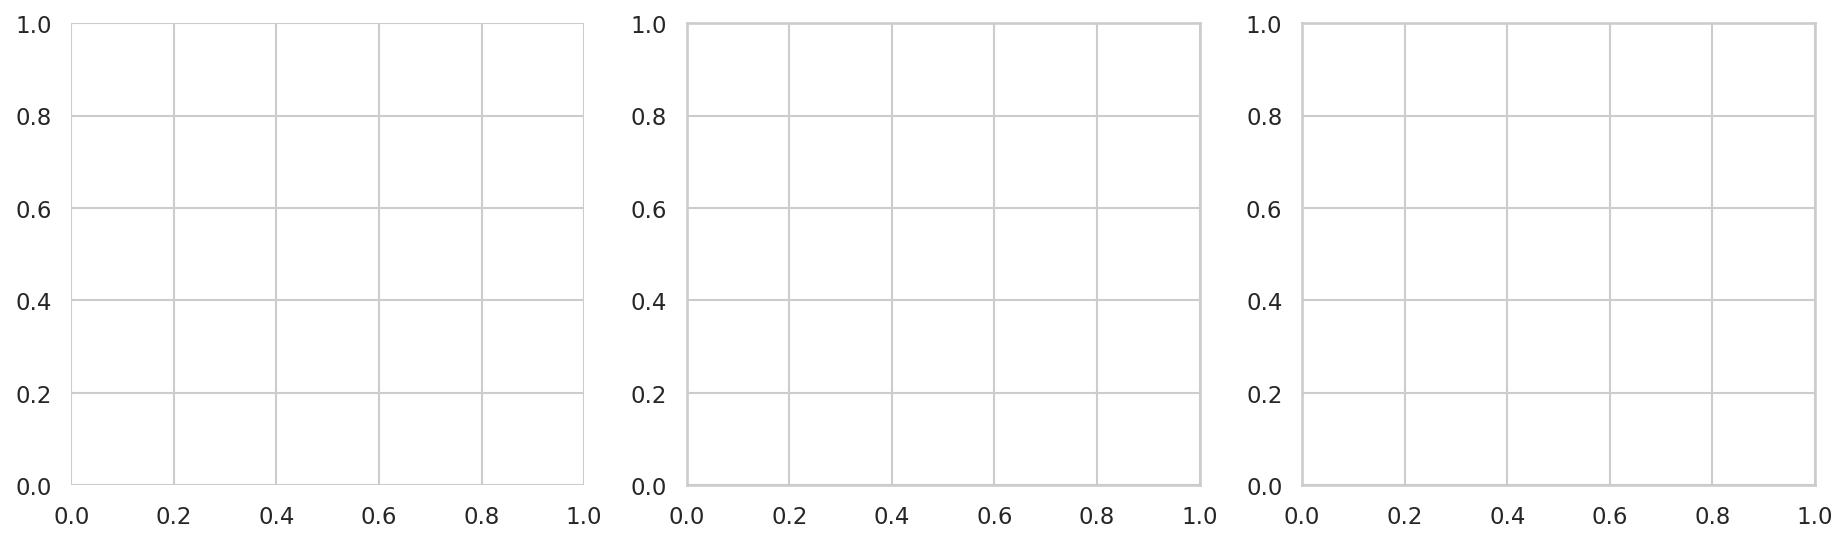

In [17]:
# Run diagnostics on REAL results
diag = Diag(results_df)
diag.run_all()
stat_tests(results_df)
abstract_stats(results_df, problems)

# Save figures to Drive
gd.save_results(results_df, "final_analyzed")

In [19]:
results_df.head()

,problem_id,model,prompt_strategy,presentation,system,tier,deontic,modal_depth,num_worlds,formula,axiom_tag,paradox_name,ground_truth,predicted,correct,response
0,MB-K-T1-QA-0011,gemini-2.5-flash,zero_shot,formal,K,1,False,1,3,◇(q),None,None,False,False,1.0,False\n\nExplanation:\nTo evaluate `◇(q)` at W...
1,MB-K-T1-QA-0010,gemini-2.5-flash,zero_shot,nl,K,1,False,1,6,□(s),None,None,False,False,1.0,False
2,MB-K-T1-QA-0020,gemini-2.5-flash,zero_shot,nl,K,1,False,1,6,□(r),None,None,True,True,1.0,True.\n\nExplanation:\nAlice is in Room F.\nFr...
3,MB-K-T1-QA-0019,gemini-2.5-flash,zero_shot,formal,K,1,False,1,6,□(r),None,None,True,True,1.0,True\n\nExplanation:\nTo evaluate □(r) at Worl...
4,MB-K-T1-QA-0009,gemini-2.5-flash,zero_shot,formal,K,1,False,1,6,□(s),None,None,False,False,1.0,False\n\n**Explanation:**\nTo evaluate `□(s)` ...


In [18]:
# ═══════════════════════════════════════════════════════════════════
# PASTE THIS CELL AFTER YOUR EVALUATION (Cell 17) — REPLACES Cell 19
# Fixes the dtype crash, runs all diagnostics, saves figures to Drive
# ═══════════════════════════════════════════════════════════════════

# ── Step 1: Fix dtypes (THE critical fix) ────────────────────────
results_df["correct"] = results_df["correct"].map(
    {"True": True, "False": False, True: True, False: False}
).astype(float)  # True→1.0, False→0.0, NaN→NaN

results_df["predicted"] = results_df["predicted"].map(
    {"True": True, "False": False, True: True, False: False}
)

print(f"✅ Fixed dtypes. Valid: {results_df.correct.notna().sum()}/{len(results_df)} "
      f"({results_df.correct.notna().mean():.1%})")
print(f"   Parse failures: gemini={results_df[results_df.model=='gemini-2.5-flash'].correct.isna().sum()}, "
      f"llama={results_df[results_df.model=='llama-70b-groq'].correct.isna().sum()}, "
      f"qwen3={results_df[results_df.model=='qwen3-235b-cerebras'].correct.isna().sum()}")

# ── Step 2: Run diagnostics ──────────────────────────────────────
diag = Diag(results_df)
diag.run_all()

# ── Step 3: Statistical tests ────────────────────────────────────
stat_tests(results_df)

# ── Step 4: Paper stats ──────────────────────────────────────────
abstract_stats(results_df, problems)

# ── Step 5: Save figures to Google Drive ─────────────────────────
import shutil
try:
    drive_fig_dir = f"{gd.base}/figures"
    os.makedirs(drive_fig_dir, exist_ok=True)
    for f in os.listdir(f"{C.OUT}/{C.FIG}"):
        shutil.copy2(f"{C.OUT}/{C.FIG}/{f}", f"{drive_fig_dir}/{f}")
    print(f"\n✅ Figures copied to {drive_fig_dir}/")
except Exception as e:
    print(f"⚠️ Drive save failed: {e} — figures still in {C.OUT}/{C.FIG}/")

✅ Fixed dtypes. Valid: 23252/27000 (86.1%)
   Parse failures: gemini=3122, llama=218, qwen3=408

DIAGNOSTIC ANALYSIS SUITE (W4)

📊 TABLE 1: Main Results (CoT strategy)
system                   D      K     S4     S5      T  Overall
model                                                          
gemini-2.5-flash     0.798  0.833  0.854  0.877  0.860    0.843
llama-70b-groq       0.702  0.669  0.727  0.734  0.761    0.718
qwen3-235b-cerebras  0.713  0.680  0.760  0.738  0.738    0.726

📊 TABLE 2: Prompting Strategy Comparison (W2)
prompt_strategy        cot  world_enum  zero_shot
model                                            
gemini-2.5-flash     0.843       0.903      0.850
llama-70b-groq       0.718       0.733      0.728
qwen3-235b-cerebras  0.726       0.655      0.792

📊 TABLE 3: Formal vs NL Gap (W1)
presentation         formal     nl    gap
model                                    
gemini-2.5-flash      0.909  0.748  0.162
llama-70b-groq        0.711  0.742 -0.031
qwen3-235b-ce

In [20]:

gd.save_results(results_df, "final_analyzed")

✅ Saved 27000 results → /content/drive/MyDrive/ICLR2026/ModalBench/results/res_final_analyzed.csv
